In [1]:
import os
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import numpy as np 
import cmocean.cm as cm
from scipy.interpolate import griddata
from matplotlib.animation import FuncAnimation, FFMpegWriter


In [ ]:
# Set your file indexer -> will be helpful for looping 
# through the text files later.
i = 1
ii = f'{i:04}'

# Open the text file.
df = pd.read_csv("textFiles/PIVLab_" + ii + ".txt", sep = ",")

# Extract the values and perform any additional
# variable calculations.
x, y = df.iloc[:,0].values, df.iloc[:,1].values
u = df.iloc[:,2].values
v = df.iloc[:,3].values
speed = (u**2 + v**2)**(1/2)

# Construct 2D meshgrid.
X, Y = np.meshgrid(x, y)

# Grid variable data to 2D meshgrid.
U = griddata((x,y), u, (X,Y))
V = griddata((x,y), v, (X,Y))
SPEED = griddata((x,y), speed, (X,Y))

<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/2k/09qtyx4526140srsbxcngrwm0000gn/T/ipykernel_27106/1006868076.py:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.colorbar(c, label = "$\sqrt{u^2 + v^2}$ [m/s]")
/var/folders/2k/09qtyx4526140srsbxcngrwm0000gn/T/ipykernel_27106/1006868076.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  c = ax[0].pcolormesh(x, y, U, cmap = cm.balance, norm = norm)
/var/folders

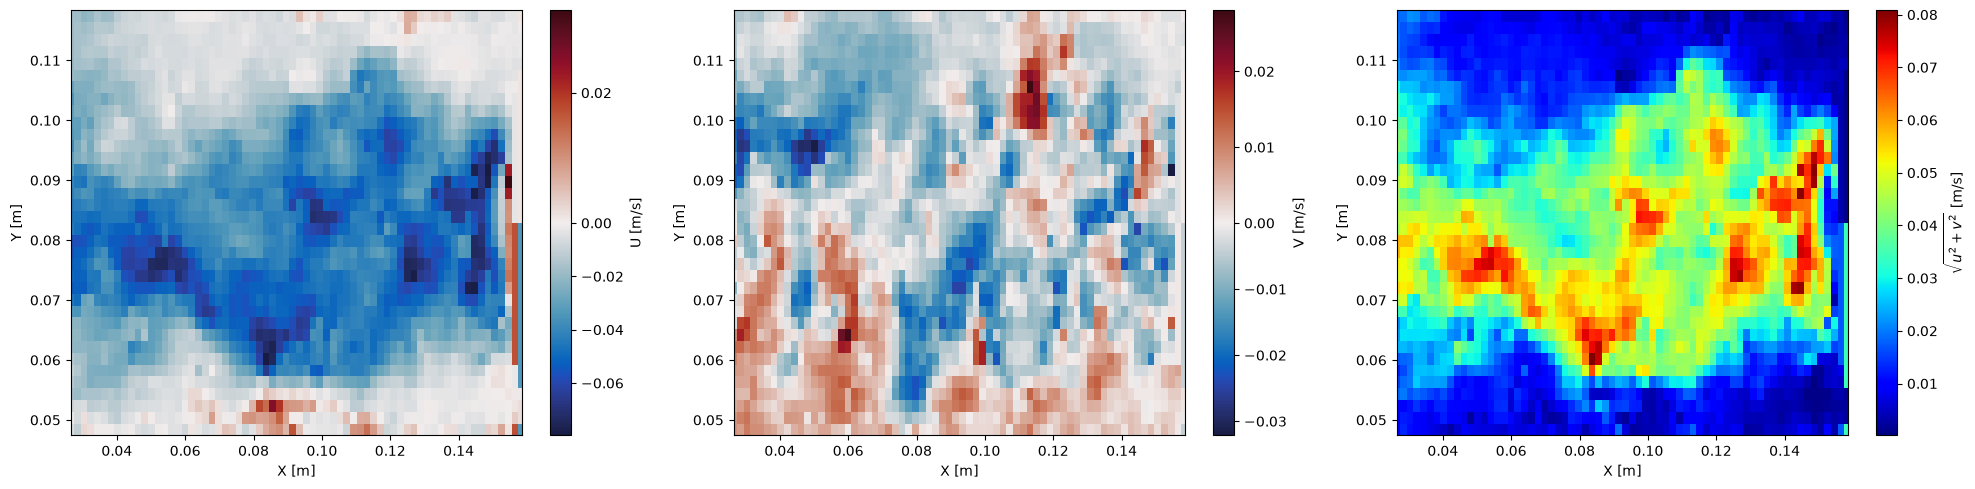

In [40]:
fig, ax = plt.subplots(1,3,figsize=(20,5))

norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=np.nanmin(U), vmax=np.nanmax(U))
c = ax[0].pcolormesh(x, y, U, cmap = cm.balance, norm = norm)
plt.colorbar(c, label = "U [m/s]")
ax[0].set_xlabel("X [m]"); ax[0].set_ylabel("Y [m]");

norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=np.nanmin(V), vmax=np.nanmax(V))
c = ax[1].pcolormesh(x, y, V, cmap = cm.balance, norm = norm)
plt.colorbar(c, label = "V [m/s]")
ax[1].set_xlabel("X [m]"); ax[1].set_ylabel("Y [m]");

c = ax[2].pcolormesh(x, y, SPEED, cmap = 'jet')
plt.colorbar(c, label = "$\sqrt{u^2 + v^2}$ [m/s]")
ax[2].set_xlabel("X [m]"); ax[2].set_ylabel("Y [m]");

plt.tight_layout()
plt.savefig("Figures/velocity" + ii + ".png", dpi = 300)

<>:43: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:43: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/2k/09qtyx4526140srsbxcngrwm0000gn/T/ipykernel_27550/140744988.py:43: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.colorbar(c, label = "$\sqrt{u^2 + v^2}$ [m/s]")


Opening file index 0001
Opening file index 0002
Opening file index 0003
Opening file index 0004
Opening file index 0005
Opening file index 0006
Opening file index 0007
Opening file index 0008
Opening file index 0009
Opening file index 0010


/var/folders/2k/09qtyx4526140srsbxcngrwm0000gn/T/ipykernel_27550/140744988.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  c = ax[0].pcolormesh(x, y, U_avg, cmap = cm.balance, norm = norm)
/var/folders/2k/09qtyx4526140srsbxcngrwm0000gn/T/ipykernel_27550/140744988.py:38: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  c = ax[1].pcolormesh(x, y, V_avg, cmap = cm.balance, norm = norm)
/var/folders/2k/09qtyx4526140srsbxcngrwm0000gn/T/ipykernel_27550/140744988.py:42: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing

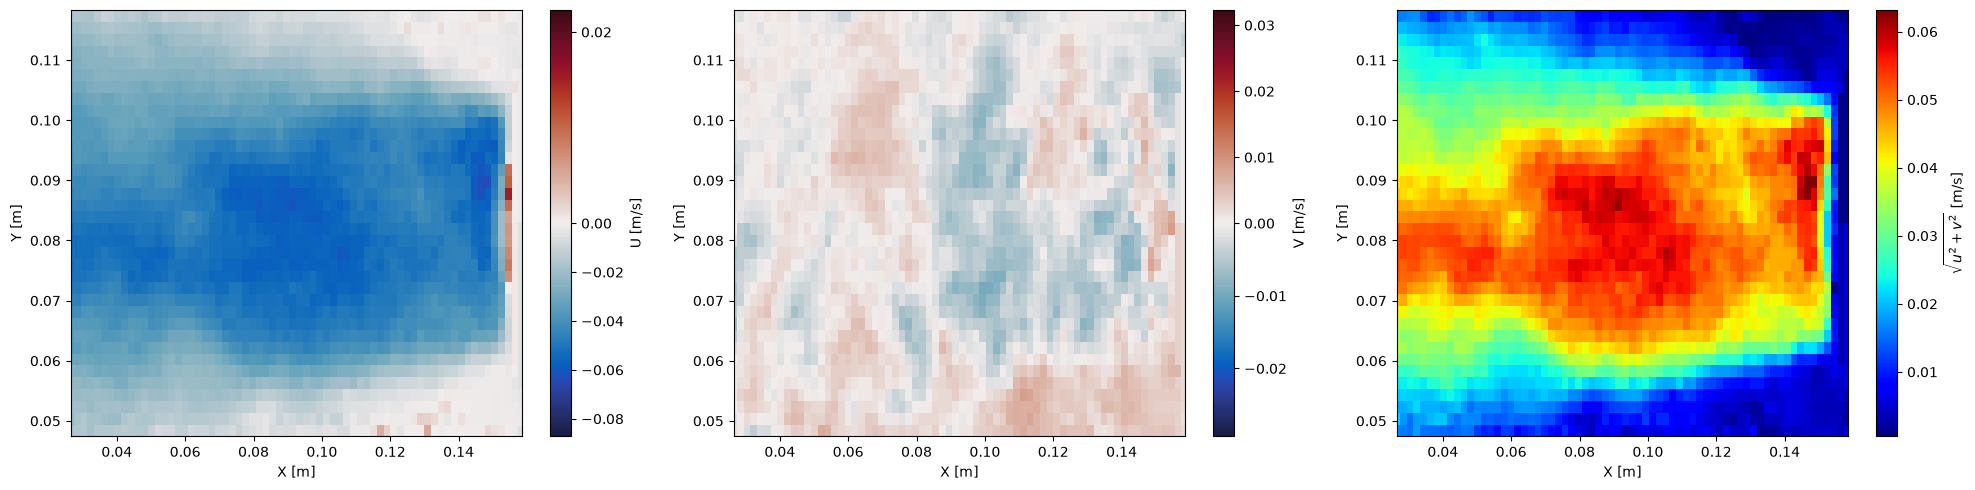

In [61]:
files = [item for item in os.listdir('textFiles') if "PIVlab" in item]
nFiles = len(files)

for i in range(1,nFiles + 1):
    
    ii = f'{i:04}'
    print(f"Opening file index {ii}")
    # Open the text file.
    df = pd.read_csv("textFiles/PIVlab_" + ii + ".txt", sep = ",")

    if i == 1:
        x, y = df.iloc[:,0].values, df.iloc[:,1].values
        X, Y = np.meshgrid(x, y)
        u_avg = np.array(df.iloc[:,2].values)
        v_avg = np.array(df.iloc[:,3].values)
    else:
        u_avg += np.array(df.iloc[:,2].values)
        v_avg += np.array(df.iloc[:,3].values)

u_avg = u_avg/nFiles
v_avg = v_avg/nFiles
speed_avg = (u_avg**2 + v_avg**2)**(1/2)

# Grid variable data to 2D meshgrid.
U_avg = griddata((x,y), u_avg, (X,Y))
V_avg = griddata((x,y), v_avg, (X,Y))
SPEED_avg = griddata((x,y), speed_avg, (X,Y))


fig, ax = plt.subplots(1,3,figsize=(20,5))

norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=np.nanmin(U), vmax=np.nanmax(U))
c = ax[0].pcolormesh(x, y, U_avg, cmap = cm.balance, norm = norm)
plt.colorbar(c, label = "U [m/s]")
ax[0].set_xlabel("X [m]"); ax[0].set_ylabel("Y [m]");

norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=np.nanmin(V), vmax=np.nanmax(V))
c = ax[1].pcolormesh(x, y, V_avg, cmap = cm.balance, norm = norm)
plt.colorbar(c, label = "V [m/s]")
ax[1].set_xlabel("X [m]"); ax[1].set_ylabel("Y [m]");

c = ax[2].pcolormesh(x, y, SPEED_avg, cmap = 'jet')
plt.colorbar(c, label = "$\sqrt{u^2 + v^2}$ [m/s]")
ax[2].set_xlabel("X [m]"); ax[2].set_ylabel("Y [m]");

plt.tight_layout()
plt.savefig("Figures/velocity_average.png", dpi = 300)

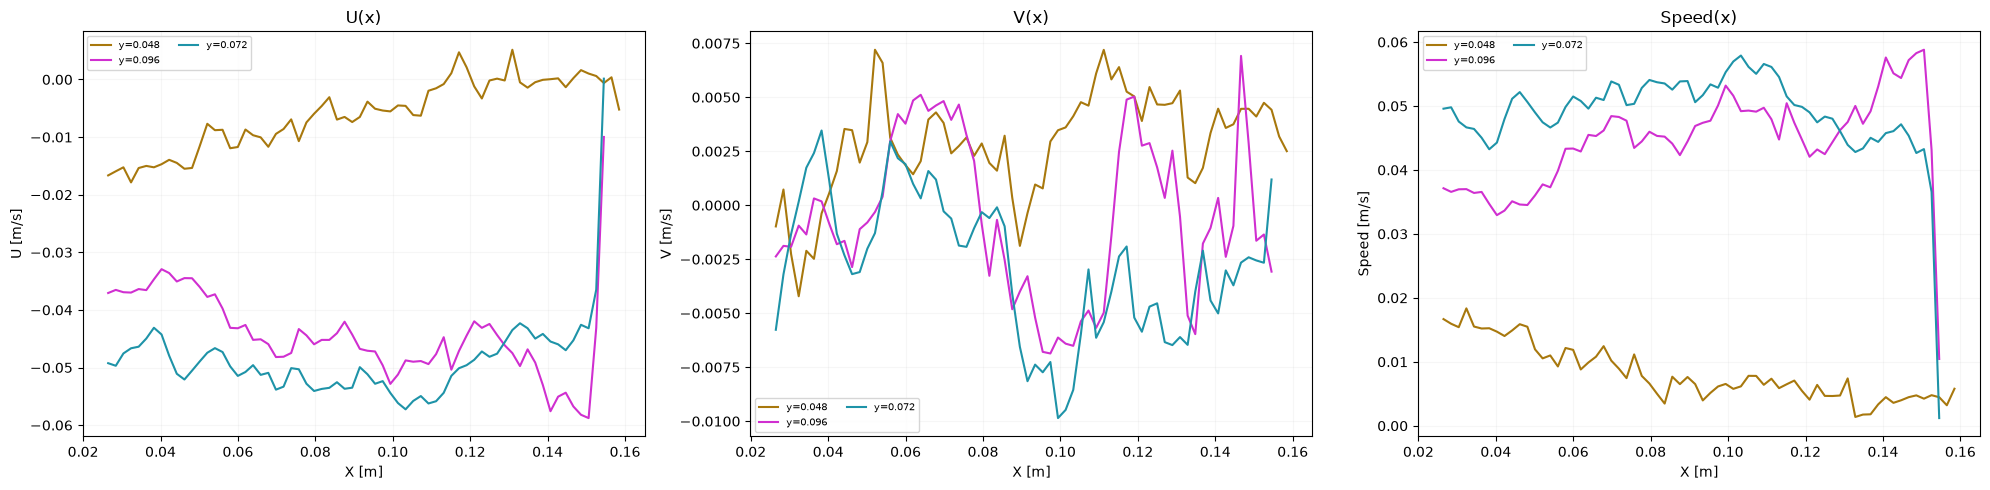

In [77]:
nY, nX = U_avg.shape
n_slices = 3
# y = np.sort(y)
# x = np.sort(x)
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# --- Row 0: horizontal slices (fixed y, profile vs x) ---
inc_y = max(1, nY // n_slices)
y_idxs = list(range(0, nY, inc_y))
cmap0 = cm.phase(np.linspace(0, 1, len(y_idxs) + 1))
for c, i in zip(cmap0, y_idxs):
    ax[0].plot(x, U_avg[i, :], color=c, label=f"y={y[i]:.3f}")
    ax[1].plot(x, V_avg[i, :], color=c, label=f"y={y[i]:.3f}")
    ax[2].plot(x, SPEED_avg[i, :], color=c, label=f"y={y[i]:.3f}")


ax[0].set_title("U(x)");     ax[1].set_title("V(x)");     ax[2].set_title("Speed(x)")

for a in ax[:]:
    a.set_xlabel("X [m]")

ax[0].set_ylabel("U [m/s]")

ax[1].set_ylabel("V [m/s]")

ax[2].set_ylabel("Speed [m/s]")

for a in ax.flat:
    a.grid(alpha=0.1)
    a.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig("Figures/velocity_transect.png", dpi = 300)



In [76]:
y_idxs

[0, 612, 1224, 1836]

In [58]:
y